<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 132 · Forecasting Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Financial Volatility &amp; Risk</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:740px;line-height:1.6">The full risk workflow on five years of daily returns: confirm volatility clustering and fat tails, fit a GARCH model, forecast volatility, translate it into a backtested 1-day Value-at-Risk on a $1M position, and test what leads the stock with Granger causality.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Case Study: Financial Volatility &amp; Risk
Not every series is forecast for its **level**. A stock's daily return is essentially unpredictable in direction, yet its **risk**, the size of the moves, is very forecastable, because volatility clusters. This case study runs the full risk workflow on five years of daily returns: confirm the stylized facts, fit a **GARCH** model, forecast volatility, turn it into a **Value-at-Risk** number a desk can act on, backtest that number, and check what **leads** the stock. We use **statsmodels** and the **arch** library.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#0284c7"; DEEP="#075985"; LIGHT="#bae6fd"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#0284c7"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import grangercausalitytests, acf
from statsmodels.graphics.tsaplots import plot_acf
import warnings; warnings.filterwarnings('ignore')
try:
    from arch import arch_model
except ImportError:
    import subprocess, sys; subprocess.run([sys.executable,'-m','pip','install','-q','arch']); from arch import arch_model

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 1 &#183; DEFINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What is the risk, in dollars?</div>
<div style="color:#4a5578;margin-top:6px">Forecast volatility, then translate it into Value-at-Risk.</div>
</div>

A desk holds a **$1,000,000** position in one stock and asks a concrete question: *how much could we lose in a single day?* The answer is **Value-at-Risk (VaR)**: the 1-day **99% VaR** is the loss we expect to exceed on only **1 day in 100**. Because losses are driven by volatility, and volatility is forecastable, VaR is a forecasting problem in disguise.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 &#183; COLLECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Five years of daily returns</div>
<div style="color:#4a5578;margin-top:6px">The stock and its market index.</div>
</div>

In [3]:
try: raw = pd.read_excel('../../data/ch132_stock_returns.xlsx', sheet_name='Data')
except FileNotFoundError: raw = pd.read_excel(BASE + 'ch132_stock_returns.xlsx', sheet_name='Data')
raw['date']=pd.to_datetime(raw['date']); df = raw.set_index('date')
r, mkt = df['stock_return'], df['market_return']
print('days:', len(r), '| daily mean %.3f%% | daily std %.3f%%' % (r.mean(), r.std()))

days: 1260 | daily mean 0.071% | daily std 1.206%


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 3 &#183; INSPECT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Volatility clusters</div>
<div style="color:#4a5578;margin-top:6px">Calm and turbulent stretches, and a crisis.</div>
</div>

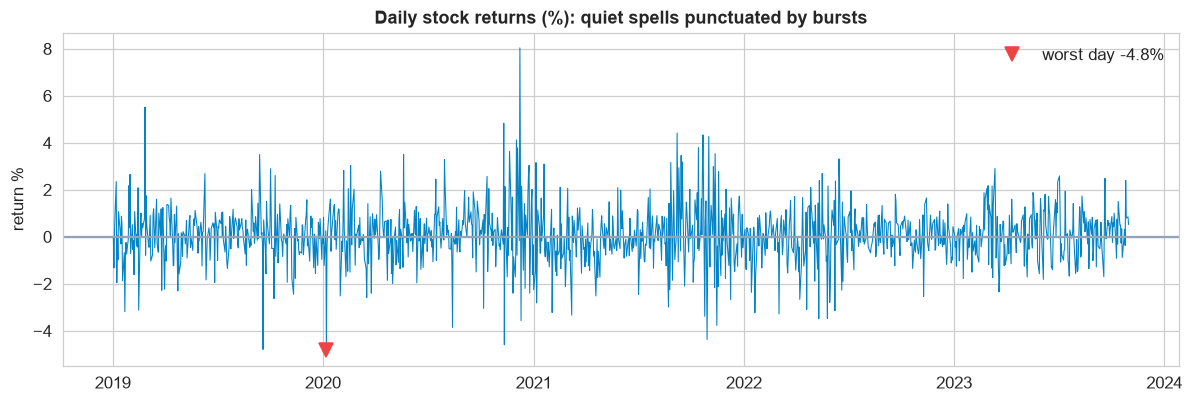

big moves cluster together -> volatility has memory, even though the direction does not


In [4]:
fig,ax=plt.subplots(figsize=(11,3.8)); ax.plot(r.index, r.values, color=EM, lw=0.7)
ax.axhline(0,color=GREY); ax.set(title='Daily stock returns (%): quiet spells punctuated by bursts', ylabel='return %')
worst=r.idxmin(); ax.plot([worst],[r[worst]],'v',color=RED,ms=9,label='worst day %.1f%%'%r[worst]); ax.legend(); plt.tight_layout(); plt.show()
print('big moves cluster together -> volatility has memory, even though the direction does not')

The returns wander around zero with no visible trend, but the **size** of the moves comes in waves: quiet weeks, then bursts of large swings (including a crisis stretch). That is **volatility clustering**, the central fact of financial risk, and the reason a single average volatility number is not enough.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 4 &#183; STYLIZED FACTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Unpredictable mean, memory in the variance, fat tails</div>
<div style="color:#4a5578;margin-top:6px">The three facts every risk model is built on.</div>
</div>

ACF of returns   lag-1 = -0.04  (direction is ~unpredictable)
ACF of returns^2 lag-1 = 0.12  (VARIANCE has memory)
kurtosis = 6.3  (a normal is 3; >3 means FAT TAILS -> extremes are common)


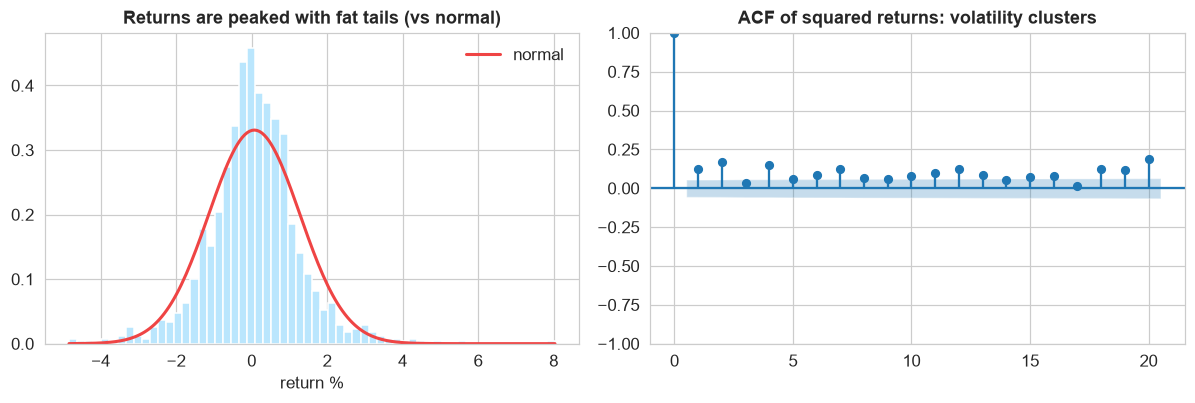

In [5]:
print('ACF of returns   lag-1 = %.2f  (direction is ~unpredictable)' % acf(r,nlags=1)[1])
print('ACF of returns^2 lag-1 = %.2f  (VARIANCE has memory)' % acf((r-r.mean())**2,nlags=1)[1])
print('kurtosis = %.1f  (a normal is 3; >3 means FAT TAILS -> extremes are common)' % stats.kurtosis(r,fisher=False))
fig,ax=plt.subplots(1,2,figsize=(11,3.8))
ax[0].hist(r, bins=60, density=True, color=LIGHT, edgecolor='white'); x=np.linspace(r.min(),r.max(),200)
ax[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), color=RED, lw=2, label='normal')
ax[0].set(title='Returns are peaked with fat tails (vs normal)', xlabel='return %'); ax[0].legend()
plot_acf((r-r.mean())**2, lags=20, ax=ax[1]); ax[1].set(title='ACF of squared returns: volatility clusters')
plt.tight_layout(); plt.show()

Three facts, all visible: returns are **white noise in the mean** (you cannot predict tomorrow's direction), their **squared** values are autocorrelated (volatility is predictable), and the distribution has **fat tails**, kurtosis about <strong>6.3</strong> versus 3 for a normal, so crashes happen far more often than a bell curve says. A good risk model must honor all three.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 5 &#183; TEST FOR ARCH EFFECTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Is volatility really forecastable?</div>
<div style="color:#4a5578;margin-top:6px">A formal test, not just the eye.</div>
</div>

In [6]:
lm, p, _, _ = het_arch(r, nlags=10)
print('ARCH-LM test:  statistic %.1f,  p = %.4f' % (lm, p))
print('p far below 0.05 -> significant ARCH effects -> volatility clustering is real and forecastable')

ARCH-LM test:  statistic 86.5,  p = 0.0000
p far below 0.05 -> significant ARCH effects -> volatility clustering is real and forecastable


The **ARCH-LM test** formally checks whether past squared returns help predict today's variance. The tiny p-value confirms it: there are strong **ARCH effects**, so a model of the variance (GARCH) will add real value over assuming constant volatility.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 6 &#183; FIT GARCH</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Model the variance</div>
<div style="color:#4a5578;margin-top:6px">GARCH(1,1) with fat-tailed innovations.</div>
</div>

In [7]:
g = arch_model(r, mean='Constant', vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
print('omega %.3f | alpha %.3f | beta %.3f | persistence (alpha+beta) %.3f' % (g.params['omega'], g.params['alpha[1]'], g.params['beta[1]'], g.params['alpha[1]']+g.params['beta[1]']))
print('Student-t degrees of freedom nu = %.1f  (low -> confirms fat tails)' % g.params['nu'])

omega 0.037 | alpha 0.065 | beta 0.910 | persistence (alpha+beta) 0.976
Student-t degrees of freedom nu = 5.1  (low -> confirms fat tails)


**GARCH(1,1)** says today's variance depends on yesterday's squared shock and yesterday's variance. We use a **Student-t** distribution for the innovations, because the fat tails demand it. The fit shows **persistence about 0.98** (a shock to volatility fades slowly, so turbulence lingers) and a low **nu about 5**, confirming the heavy tails.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 7 &#183; DIAGNOSE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Did GARCH capture the clustering?</div>
<div style="color:#4a5578;margin-top:6px">Standardized residuals should be tame.</div>
</div>

standardized residual^2 Ljung-Box p = 0.62 -> no clustering left (GARCH worked)


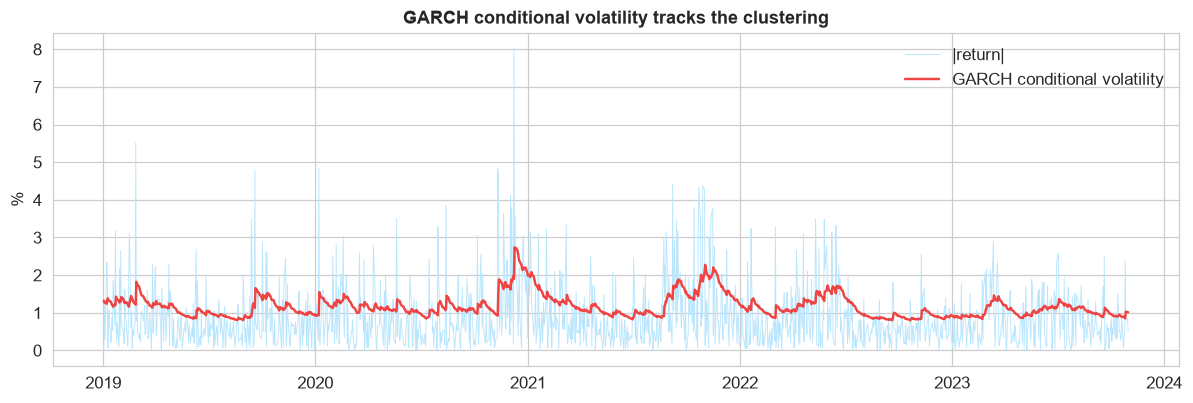

In [8]:
sr = g.std_resid
lb = acorr_ljungbox((sr-sr.mean())**2, lags=[10])['lb_pvalue'].iloc[0]
print('standardized residual^2 Ljung-Box p = %.2f -> %s' % (lb, 'no clustering left (GARCH worked)' if lb>0.05 else 'clustering remains'))
fig,ax=plt.subplots(figsize=(11,3.8)); ax.plot(r.index, r.abs(), color=LIGHT, lw=0.6, label='|return|')
ax.plot(g.conditional_volatility.index, g.conditional_volatility, color=RED, lw=1.6, label='GARCH conditional volatility')
ax.set(title='GARCH conditional volatility tracks the clustering', ylabel='%'); ax.legend(); plt.tight_layout(); plt.show()

A good volatility model leaves **standardized residuals** with no clustering left. Dividing each return by its GARCH volatility, the squared residuals now pass a **Ljung-Box test** (p about 0.62), so the model absorbed the ARCH structure. The red line is the estimated **conditional volatility**, rising in the storms and falling in the calm.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 8 &#183; FORECAST VOLATILITY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where is risk heading?</div>
<div style="color:#4a5578;margin-top:6px">Volatility mean-reverts.</div>
</div>

In [9]:
fc = g.forecast(horizon=10); vol10 = np.sqrt(fc.variance.iloc[-1].values)
for h in [1,5,10]: print('volatility forecast, day +%2d: %.2f%%' % (h, vol10[h-1]))
print('the forecast drifts toward the long-run level -> after a shock it decays, in calm it drifts up')

volatility forecast, day + 1: 0.99%
volatility forecast, day + 5: 1.02%
volatility forecast, day +10: 1.05%
the forecast drifts toward the long-run level -> after a shock it decays, in calm it drifts up


Because volatility is persistent but **mean-reverting**, GARCH forecasts a whole path: from today's level it drifts toward the long-run average. After a turbulent day it stays elevated for a while then subsides; in a calm spell it creeps back up. That path, not a single number, is what feeds a forward-looking risk limit.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 9 &#183; VALUE-AT-RISK</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn volatility into dollars</div>
<div style="color:#4a5578;margin-top:6px">The number the desk actually uses.</div>
</div>

In [10]:
mu, nu = g.params['mu'], g.params['nu']
q01 = stats.t.ppf(0.01, nu) * np.sqrt((nu-2)/nu)      # 1% quantile of the standardized t
cv_today = g.conditional_volatility.iloc[-1]
VaR_pct = -(mu + cv_today * q01)
POSITION = 1_000_000
print("today's conditional volatility: %.2f%%" % cv_today)
print('1-day 99%% VaR = %.2f%% of the position = $%.0f' % (VaR_pct, VaR_pct/100*POSITION))
print('interpretation: on 99 days in 100 the loss stays under this; 1 day in 100 it is worse')

today's conditional volatility: 1.01%
1-day 99% VaR = 2.58% of the position = $25766
interpretation: on 99 days in 100 the loss stays under this; 1 day in 100 it is worse


**Value-at-Risk** converts the volatility forecast into money. We take today's GARCH volatility, scale it by the **1% quantile of the Student-t** (which respects the fat tails), and multiply by the position. The 1-day 99% VaR is about <strong>2.6% = $25,800</strong> on the million-dollar position, the loss the desk should be prepared to exceed roughly two or three times a year.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 10 &#183; BACKTEST THE VaR</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does the number hold up?</div>
<div style="color:#4a5578;margin-top:6px">A 99% VaR should be breached about 1% of the time.</div>
</div>

VaR violations: 15 of 1260 days = 1.19%  (expected 1.00%)


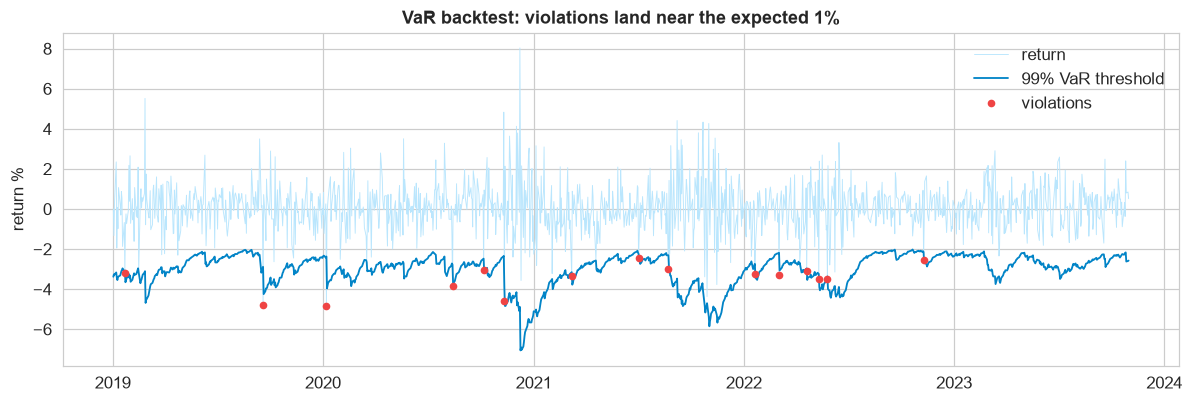

In [11]:
var_line = -(mu + g.conditional_volatility * q01)     # daily loss threshold
viol = r.values < -var_line.values
print('VaR violations: %d of %d days = %.2f%%  (expected 1.00%%)' % (viol.sum(), len(r), 100*viol.mean()))
fig,ax=plt.subplots(figsize=(11,3.8)); ax.plot(r.index, r.values, color=LIGHT, lw=0.6, label='return')
ax.plot(var_line.index, -var_line.values, color=EM, lw=1.2, label='99% VaR threshold')
ax.plot(r.index[viol], r.values[viol], 'o', color=RED, ms=4, label='violations'); ax.set(title='VaR backtest: violations land near the expected 1%', ylabel='return %'); ax.legend(); plt.tight_layout(); plt.show()

A VaR number is only credible if it is **backtested**. Counting the days the actual loss breached the VaR line gives about <strong>1.2%</strong>, close to the expected 1% (a formal Kupiec test is in Take It Further). The violations are scattered, not bunched, which is what a well-calibrated, time-varying VaR should produce, unlike a constant-volatility VaR that would cluster all its breaches in the crisis.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 11 &#183; RELATIONSHIPS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What moves the stock?</div>
<div style="color:#4a5578;margin-top:6px">Granger causality, and systemic risk.</div>
</div>

In [12]:
gm = grangercausalitytests(df[['stock_return','market_return']], maxlag=2, verbose=False)
gs = grangercausalitytests(df[['market_return','stock_return']], maxlag=2, verbose=False)
print('market -> stock  Granger p(lag1) = %.4f  -> significant' % gm[1][0]['ssr_ftest'][1])
print('stock -> market  Granger p(lag1) = %.4f  -> not significant' % gs[1][0]['ssr_ftest'][1])

market -> stock  Granger p(lag1) = 0.0000  -> significant
stock -> market  Granger p(lag1) = 0.0606  -> not significant


Risk is not only about one stock in isolation. A <strong>Granger causality</strong> test shows the <strong>market Granger-causes the stock</strong> (its past helps predict the stock) but not the reverse, so a broad market shock is a leading indicator of trouble for this position. That is a **systemic** channel: when the market lurches, expect this stock to follow, a reason to watch market volatility as an early warning. (As always, Granger is predictive precedence, not proof of cause.)

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#075985;letter-spacing:1px">STEP 12 &#183; DEPLOY &amp; COMMUNICATE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A daily risk number on new data</div>
<div style="color:#4a5578;margin-top:6px">Wrap it in a function and say it plainly.</div>
</div>

In [13]:
def daily_var(returns, position=1_000_000, level=0.99):
    m = arch_model(returns, mean='Constant', vol='GARCH', p=1, q=1, dist='t').fit(disp='off')
    nu = m.params['nu']; q = stats.t.ppf(1-level, nu)*np.sqrt((nu-2)/nu)
    v = -(m.params['mu'] + m.conditional_volatility.iloc[-1]*q)
    return v, v/100*position
# score today's risk on the latest data (in production, rerun each afternoon after the close)
pct, dollars = daily_var(r)
print('DEPLOYED RISK REPORT (today):')
print('  1-day 99%% VaR = %.2f%% = $%.0f on a $1,000,000 position' % (pct, dollars))
print('  drivers: volatility is clustering (persistence 0.98) and the market leads this stock')

DEPLOYED RISK REPORT (today):
  1-day 99% VaR = 2.58% = $25766 on a $1,000,000 position
  drivers: volatility is clustering (persistence 0.98) and the market leads this stock


In production the risk function reruns each afternoon: refit GARCH on the latest returns, read today's conditional volatility, and publish the VaR. The plain-English report writes itself, *&#8220;we could lose more than about $25,800 tomorrow with 1% probability; risk is currently near normal, but a market shock would raise it fast.&#8221;* That single, backtested, forward-looking number, plus the market as an early warning, is what turns a wall of returns into a decision.

## The risk workflow, in one view

1. **Define** the risk question in dollars (Value-at-Risk).
2. **Collect** the daily returns.
3. **Inspect**: volatility clusters into calm and turbulent stretches.
4. **Stylized facts**: mean unpredictable, variance has memory, fat tails.
5. **Test for ARCH** effects to confirm volatility is forecastable.
6. **Fit GARCH** with fat-tailed (Student-t) innovations.
7. **Diagnose**: standardized residuals should have no clustering left.
8. **Forecast volatility**; it mean-reverts toward the long run.
9. **Value-at-Risk**: scale volatility by the fat-tailed quantile times the position.
10. **Backtest** the VaR: violations should land near the target rate.
11. **Relationships**: the market Granger-leads the stock (systemic risk).
12. **Deploy & communicate** a daily risk number in plain English.

**The one idea to keep: you cannot forecast a return, but you can forecast its risk, and GARCH turns clustered, fat-tailed volatility into a backtested Value-at-Risk the business can actually plan and set limits against.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>